In [229]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('Student_performance_data _.csv')

X = df.drop(columns=['StudentID', 'GradeClass', 'GPA'])
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]
num_classes = len(np.unique(y))

print(f"Dimensión de entrada: {input_dim}")
print(f"Cantidad de clases: {num_classes}")

Dimensión de entrada: 12
Cantidad de clases: 5


In [230]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(optimizer='adam'):
    model = Sequential()
    
    model.add(Dense(200, input_dim=input_dim, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(200, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(150, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(200, activation='relu'))
    model.add(Dropout(0.2))
    
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(loss='sparse_categorical_crossentropy', 
                  optimizer=optimizer, 
                  metrics=['accuracy'])
    
    return model

In [231]:
optimizador = 'sgd'
epocas = 50
batch_size = 16

model = build_model(optimizer=optimizador)

history = model.fit(X_train_scaled, y_train, 
                    validation_split=0.3, 
                    epochs=epocas, 
                    batch_size=batch_size, 
                    verbose=1)

val_acc_final = history.history['val_accuracy'][-1]
val_loss_final = history.history['val_loss'][-1]

print(f"Exactitud: {val_acc_final:.4f}")
print(f"Pérdida: {val_loss_final:.4f}")

Epoch 1/50


/home/dante/neuronales/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 9s 92ms/step - accuracy: 0.4552 - loss: 1.4907 - val_accuracy: 0.5527 - val_loss: 1.3553
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4859 - loss: 1.3702 - val_accuracy: 0.5527 - val_loss: 1.2574
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4859 - loss: 1.3023 - val_accuracy: 0.5527 - val_loss: 1.1857
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4859 - loss: 1.2325 - val_accuracy: 0.5527 - val_loss: 1.1059
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4919 - loss: 1.1675 - val_accuracy: 0.5706 - val_loss: 1.0226
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5260 - loss: 1.1014 - val_accuracy: 0.6282 - val_loss: 0.9552
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5739 - loss: 1.0386 - val_accuracy: 0.6680 - val_loss: 0.9063
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6055 - loss: 0.9979 - val_accuracy: 0.6759 - val_loss: 0.8724
Ep

In [232]:
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=1)

print(f"\nExactitud en test: {test_acc:.4f}")
print(f"Pérdida en test: {test_loss:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7396 - loss: 0.7529

Exactitud en test: 0.7396
Pérdida en test: 0.7529


Ranking de Importancia de Características
   Característica  Fisher Score
         Absences    610.600949
  ParentalSupport     10.621138
  StudyTimeWeekly      7.561239
         Tutoring      5.710958
  Extracurricular      2.718787
        Ethnicity      1.838721
ParentalEducation      1.440918
            Music      1.391085
           Sports      0.573702
     Volunteering      0.560862
           Gender      0.501372
              Age      0.149584


/tmp/ipykernel_1109/436831783.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Fisher Score', y='Característica', data=df_fisher, palette='viridis')


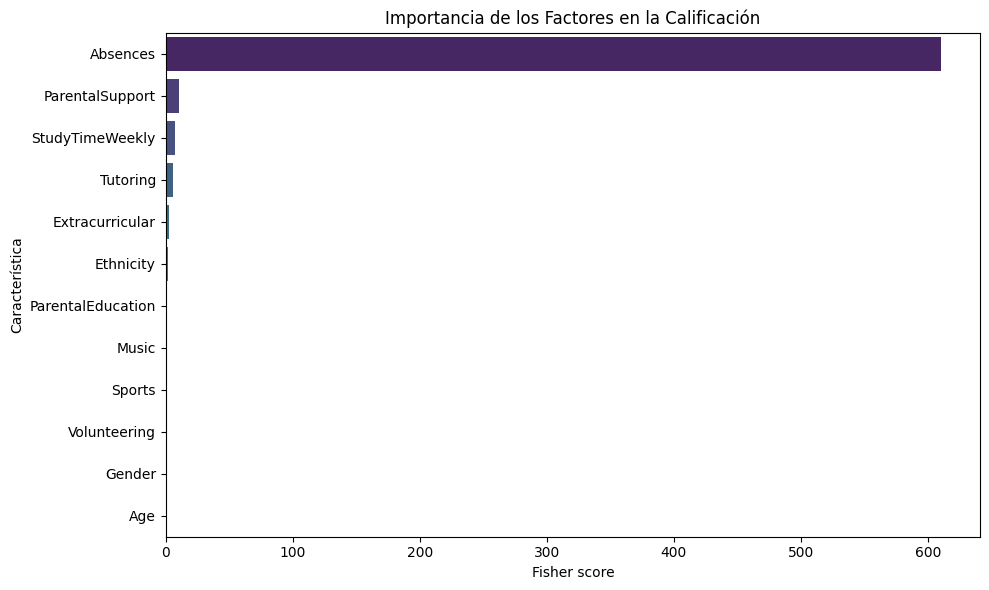

In [233]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import f_classif
import pandas as pd

fisher_scores, p_values = f_classif(X_train_scaled, y_train)

df_fisher = pd.DataFrame({
    'Característica': X.columns,
    'Fisher Score': fisher_scores
})

df_fisher = df_fisher.sort_values(by='Fisher Score', ascending=False)

print("Ranking de Importancia de Características")
print(df_fisher.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Fisher Score', y='Característica', data=df_fisher, palette='viridis')
plt.title('Importancia de los Factores en la Calificación')
plt.xlabel('Fisher score')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step


/home/dante/neuronales/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dante/neuronales/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/dante/neuronales/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        32
         1.0       0.58      0.65      0.62        81
         2.0       0.61      0.62      0.61       117
         3.0       0.57      0.55      0.56       124
         4.0       0.87      0.93      0.90       364

    accuracy                           0.74       718
   macro avg       0.53      0.55      0.54       718
weighted avg       0.70      0.74      0.72       718



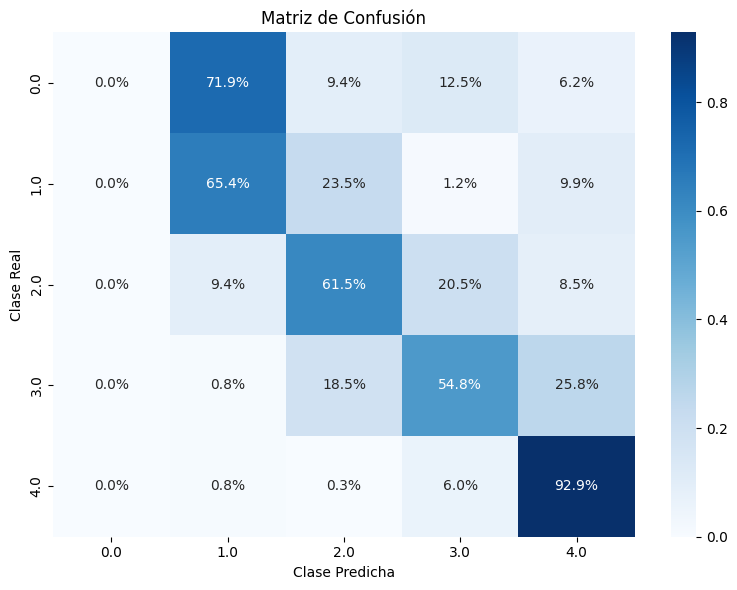

In [235]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

print(classification_report(y_test, y_pred))

cm_normalized = confusion_matrix(y_test, y_pred, normalize='true')

plt.figure(figsize=(8, 6))

sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues', 
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Matriz de Confusión')
plt.ylabel('Clase Real')
plt.xlabel('Clase Predicha')
plt.tight_layout()
plt.show()